In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [44]:
hours = np.random.randint(1, 20, 100)
grades = 5 + 4 * hours + np.random.normal(0, 5, 100)  # y = 5 + 4x
print(hours.shape, grades.shape)

(100,) (100,)


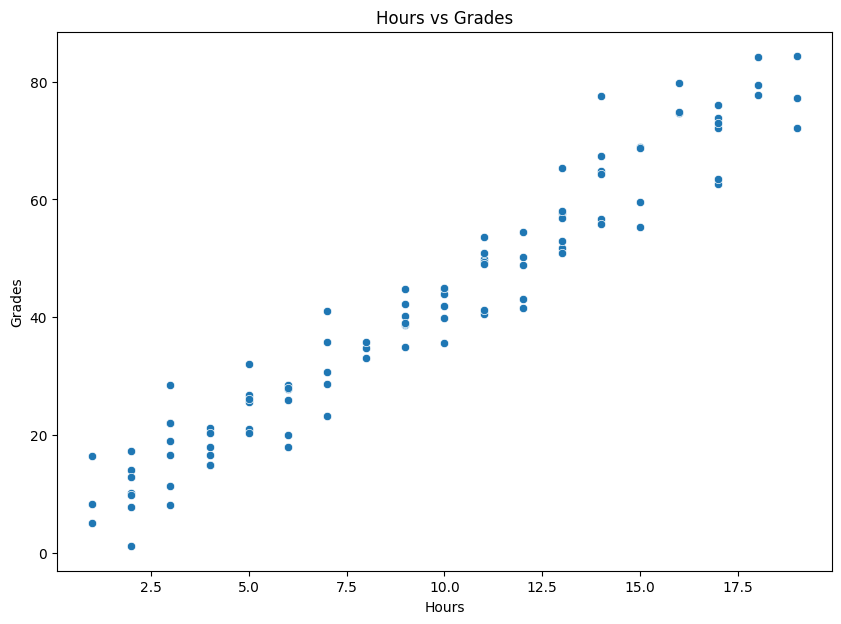

In [45]:
plt.figure(figsize=(10, 7))
sns.scatterplot(x=hours, y=grades)
plt.xlabel('Hours')
plt.ylabel('Grades')
plt.title('Hours vs Grades')
plt.show()

In [46]:
hours_train = hours[:70]
grades_train = grades[:70]
hours_test = hours[70:]
grades_test = grades[70:]

In [47]:
from sklearn.linear_model import LinearRegression
# tạo mô hình
model = LinearRegression()
# huấn luyện mô hình
model.fit(hours_train.reshape(-1, 1), grades_train)

LinearRegression()

X => MxN (n_samples, n_features)

hours => vector (100,)

reshape(-1, 1) => (100,) => (100,1)

(20, 30, 33, .., 40)

=>

[20,

 30,

 33,

 ..

 40]

In [48]:
# xác định hệ số góc và intercept
w1 = model.coef_[0]
w0 = model.intercept_
print(w1, w0)         # y = 3.88 + 4.16*x

4.082512791277766 3.2806265696267047


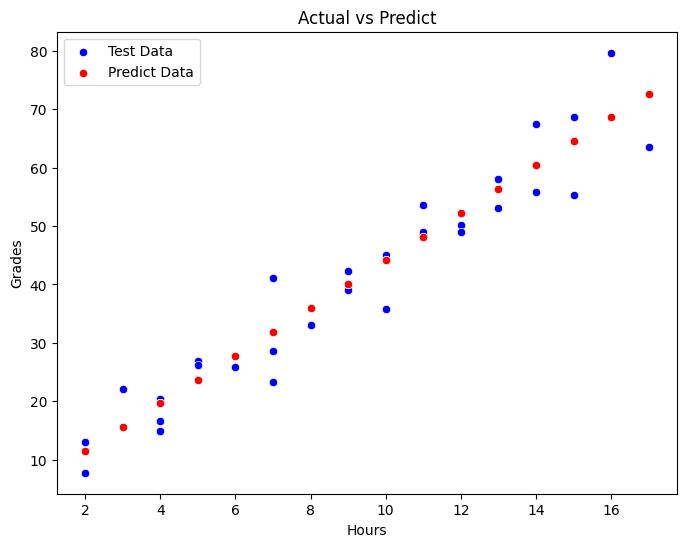

In [49]:
grades_predict = model.predict(hours_test.reshape(-1, 1))

plt.figure(figsize=(8, 6))
sns.scatterplot(x=hours_test, y=grades_test, label='Test Data', color='blue')
sns.scatterplot(x=hours_test, y=grades_predict, label='Predict Data', color='red')
plt.xlabel('Hours')
plt.ylabel('Grades')
plt.title('Actual vs Predict')
plt.show()

In [50]:
mse = np.mean((grades_test - grades_predict)**2)
print(mse)
r2  = model.score(hours_test.reshape(-1, 1), grades_test)
print(r2)

27.5338700473127
0.9212153852704742


In [51]:
df = pd.read_csv('data_simple_reg.csv')
df.head()

,TT,Quang_Cao,Tiep_Thi,Online,Doanh_So
0,0,12.0,5.993562,3.730133,79.732757
1,1,13.0,6.741511,3.006753,71.677897
2,2,41.0,15.405956,2.987338,175.177829
3,3,78.0,28.294987,6.934639,323.246340
4,4,11.0,6.663944,1.633811,81.594181


In [52]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4572 entries, 0 to 4571
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TT         4572 non-null   int64  
 1   Quang_Cao  4562 non-null   float64
 2   Tiep_Thi   4568 non-null   float64
 3   Online     4566 non-null   float64
 4   Doanh_So   4566 non-null   float64
dtypes: float64(4), int64(1)
memory usage: 178.7 KB


In [53]:
df = df.dropna()
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 4546 entries, 0 to 4571
Data columns (total 5 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TT         4546 non-null   int64  
 1   Quang_Cao  4546 non-null   float64
 2   Tiep_Thi   4546 non-null   float64
 3   Online     4546 non-null   float64
 4   Doanh_So   4546 non-null   float64
dtypes: float64(4), int64(1)
memory usage: 213.1 KB


In [54]:
from sklearn.model_selection import train_test_split

In [55]:
X = df['Quang_Cao']
y = df['Doanh_So']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [56]:
print(X_train.shape, X_test.shape, y_train.shape, y_test.shape)

(3636,) (910,) (3636,) (910,)


In [57]:
model = LinearRegression()
model.fit(X_train.values.reshape(-1, 1), y_train)

LinearRegression()

In [58]:
w1 = model.coef_[0]
w0 = model.intercept_
print(f'Phương trình hồi quy: y = {w1:.2f}x + {w0:.2f}')

Phương trình hồi quy: y = 3.52x + 42.68


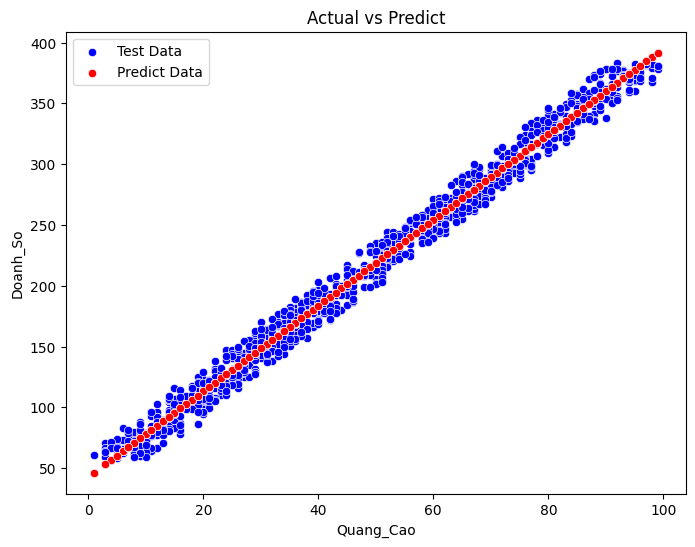

In [59]:
y_pred = model.predict(X_test.values.reshape(-1, 1))

plt.figure(figsize=(8, 6))
sns.scatterplot(x=X_test, y=y_test, label='Test Data', color='blue')
sns.scatterplot(x=X_test, y=y_pred, label='Predict Data', color='red')
plt.xlabel('Quang_Cao')
plt.ylabel('Doanh_So')
plt.title('Actual vs Predict')
plt.show()

In [60]:
from sklearn.metrics import mean_squared_error, r2_score

r2 = r2_score(y_test, y_pred)
print(f'R2 Score: {r2:.2f}')
mse = mean_squared_error(y_test, y_pred)
print(f'MSE: {mse:.2f}')

R2 Score: 0.99
MSE: 106.37


In [61]:
df = pd.read_csv('data_multiple_reg.csv')
df.head()

,TT,Quang_Cao,PR,Online,KOL,Doanh_So
0,0,Low,1.034766,4.297423,Micro,80.261284
1,1,Low,5.340160,0.744989,Mega,92.574904
2,2,High,21.918056,0.004401,Micro,297.250108
3,3,Medium-High,20.288928,0.688838,Mega,220.102176
4,4,High,30.048338,7.365014,Nano,298.960377


In [62]:
df.describe()

,TT,PR,Online,Doanh_So
count,572.000000,572.000000,572.000000,572.000000
mean,285.500000,17.575863,3.408835,214.296908
std,165.266452,9.354603,2.544451,89.871581
min,0.000000,0.132418,0.000031,58.509810
25%,142.750000,10.558676,1.343825,143.718722
50%,285.500000,17.449277,3.028044,209.005362
75%,428.250000,24.363093,4.820536,289.500118
max,571.000000,40.574350,11.713146,382.788195


In [63]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 572 entries, 0 to 571
Data columns (total 6 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TT         572 non-null    int64  
 1   Quang_Cao  572 non-null    object 
 2   PR         572 non-null    float64
 3   Online     572 non-null    float64
 4   KOL        572 non-null    object 
 5   Doanh_So   572 non-null    float64
dtypes: float64(3), int64(1), object(2)
memory usage: 26.9+ KB


In [64]:
X = df[['PR', 'Online']]
y = df['Doanh_So']

In [65]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=10)
model = LinearRegression()
model.fit(X_train, y_train)

W = model.coef_
w0 = model.intercept_
print(W, w0)

[8.23090819 0.40562972] 70.26020775341163


In [66]:
print(f'Phương trình dự báo: y = {W[0]:.2f}PR + {W[1]:.2f}Online + {w0:.2f}')

Phương trình dự báo: y = 8.23PR + 0.41Online + 70.26


In [67]:
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f'R2 Score: {r2:.2f}')
mse = mean_squared_error(y_test, y_pred)
print(f'MSE: {mse:.2f}')

R2 Score: 0.72
MSE: 2262.13


In [69]:
df = pd.read_csv('data_multiple_reg.csv')
df.head()

,TT,Quang_Cao,PR,Online,KOL,Doanh_So
0,0,Low,1.034766,4.297423,Micro,80.261284
1,1,Low,5.340160,0.744989,Mega,92.574904
2,2,High,21.918056,0.004401,Micro,297.250108
3,3,Medium-High,20.288928,0.688838,Mega,220.102176
4,4,High,30.048338,7.365014,Nano,298.960377


In [71]:
qc_encoded = pd.get_dummies(df['Quang_Cao'], prefix='QC')
X = pd.concat([df[['PR', 'Online']], qc_encoded], axis=1)
y = df['Doanh_So']
X.head()

,PR,Online,QC_High,QC_Low,QC_Medium-High,QC_Medium-Low
0,1.034766,4.297423,False,True,False,False
1,5.340160,0.744989,False,True,False,False
2,21.918056,0.004401,True,False,False,False
3,20.288928,0.688838,False,False,True,False
4,30.048338,7.365014,True,False,False,False


In [84]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=10)
model = LinearRegression()
model.fit(X_train, y_train)

W = model.coef_
w0 = model.intercept_
print(W, w0)

[  2.2994221    0.24886241  83.3504066  -83.70047587  24.13682284
 -23.78675357] 178.56581227918883


In [85]:
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f'R2 Score: {r2:.2f}')
mse = mean_squared_error(y_test, y_pred)
print(f'MSE: {mse:.2f}')

R2 Score: 0.92
MSE: 603.68
